In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
import os

base = '/content/drive/MyDrive/Cliniscan_Project'
images_dir = os.path.join(base, 'png_images')
labels_dir = os.path.join(base, 'yolo_labels')

print("Number of images:", len(os.listdir(images_dir)))
print("Number of labels:", len(os.listdir(labels_dir)))

#  first few files
print("\nFirst 5 images:", os.listdir(images_dir)[:5])
print("First 5 labels:", os.listdir(labels_dir)[:5])

Number of images: 15000
Number of labels: 15000

First 5 images: ['47d293c136a5858fea31196036e741da.png', '47c3686f8cded6214f73a1de3d8f0682.png', '47c99f1ff7abe52d6dcdf4414db20e2c.png', '47ef9b0009481d207e15dc4b31ab9c2f.png', '47dac5cee95f45895aa752a0317b94f8.png']
First 5 labels: ['ee5f83857d2f92db7596c009c1ce3dba.txt', 'ede5ee0593a81c523395c96c66983456.txt', 'ee4bb5df5cdac0243ce8b6cbc2dbe246.txt', 'ee6eeaf541a305708e7a477a9def0488.txt', 'edd63fab835b3c6492a5ec8b8a3446d3.txt']


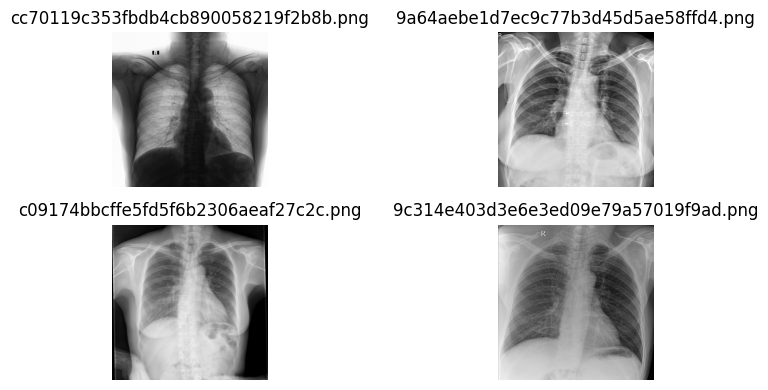

Basic data loading & displaying sample images


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import random

# taking 4 random images
all_pngs = [f for f in os.listdir(images_dir) if f.endswith('.png')]
random_samples = random.sample(all_pngs, min(4, len(all_pngs)))

plt.figure(figsize=(10, 4))

for i, fname in enumerate(random_samples):
    img_path = os.path.join(images_dir, fname)
    label_path = os.path.join(labels_dir, fname.replace('.png', '.txt'))

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(2, 2, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(fname)
    plt.axis('off')

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            label_content = f.read().strip()
        plt.xlabel(f"Labels: {label_content[:50]}{'...' if len(label_content) > 50 else ''}")
    else:
        plt.xlabel("No label file")

plt.tight_layout()
plt.show()

print("Basic data loading & displaying sample images")

In [ ]:
!pip install ultralytics -q
from ultralytics import YOLO
print("YOLOv8 installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 installed successfully!


In [10]:
import os

print("Checking paths...")

images_path = os.path.join(base, "png_images")
labels_path = os.path.join(base, "yolo_labels")

print("Images folder exists?", os.path.exists(images_path))
print("Labels folder exists?", os.path.exists(labels_path))

if os.path.exists(images_path):
    print("Number of images:", len([f for f in os.listdir(images_path) if f.endswith('.png')]))
else:
    print("Images path not found - check spelling/capitalization")

if os.path.exists(labels_path):
    print("Number of label files:", len([f for f in os.listdir(labels_path) if f.endswith('.txt')]))
else:
    print("Labels path not found")

Checking paths...
Images folder exists? True
Labels folder exists? True
Number of images: 15000
Number of label files: 15000


In [8]:

BASE = '/content/drive/MyDrive/Cliniscan_Project'

yaml_content = f"""
path: {BASE}

train: png_images
val:   png_images

train_fraction: 0.8    # 80% train, 20% val — automatic random split by YOLOv8

nc: 14
names:
  0: Aortic enlargement
  1: Atelectasis
  2: Calcified granuloma
  3: Cardiomegaly
  4: Consolidation
  5: ILD
  6: Infiltration
  7: Lung opacity
  8: Nodule/Mass
  9: Other lesion
  10: Pleural effusion
  11: Pleural thickening
  12: Pneumonia
  13: Pulmonary fibrosis
"""

with open('/content/dataset.yaml', 'w') as f:
    f.write(yaml_content)

print("dataset.yaml ready")
!cat /content/dataset.yaml

dataset.yaml ready

path: /content/drive/MyDrive/Cliniscan_Project

train: png_images
val:   png_images

train_fraction: 0.8    # 80% train, 20% val — automatic random split by YOLOv8

nc: 14
names:
  0: Aortic enlargement
  1: Atelectasis
  2: Calcified granuloma
  3: Cardiomegaly
  4: Consolidation
  5: ILD
  6: Infiltration
  7: Lung opacity
  8: Nodule/Mass
  9: Other lesion
  10: Pleural effusion
  11: Pleural thickening
  12: Pneumonia
  13: Pulmonary fibrosis
